# Dataset Attribution Using Gradient-Based Methods

Efficient training data attribution using BM25 retrieval, gradient similarity, and influence proxies.  
This notebook analyzes how training samples influence model behavior using scalable, gradient-based approximations.

## 1. Environment Setup and Configuration

This section defines libraries, configuration parameters, and runtime settings used across the notebook.  
It ensures reproducibility for gradient computation and attribution experiments.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q --no-deps rank-bm25 peft accelerate sentence-transformers

In [3]:
import os
from pathlib import Path


# PATH CONFIG
DRIVE_ROOT = "/content/drive/MyDrive/dataset-attribution-artifacts"
REPO_DIR   = "/content/Dataset-Attribution"

RUN_ID       = "final_report_run"
SPLIT_RUN_ID = "default_run"

OUTPUT_ROOT = os.path.join(DRIVE_ROOT, "outputs", "runs")

# correct train run directory
TRAIN_DIR = os.path.join(OUTPUT_ROOT, RUN_ID, "train")

ADAPTER_DIR   = os.path.join(TRAIN_DIR, "adapter")
TOKENIZER_DIR = os.path.join(TRAIN_DIR, "tokenizer")

TRAIN_CSV  = os.path.join(OUTPUT_ROOT, SPLIT_RUN_ID, "splits", "train.csv")
TEST_CSV   = os.path.join(OUTPUT_ROOT, SPLIT_RUN_ID, "splits", "test.csv")
SHADOW_CSV = os.path.join(OUTPUT_ROOT, SPLIT_RUN_ID, "splits", "shadow.csv")  # optional

ALPACA_JSON_CANDIDATES = [
    os.path.join(REPO_DIR, "data", "raw", "alpaca_data.json"),
    os.path.join(DRIVE_ROOT, "data", "raw", "alpaca_data.json"),
    os.path.join(DRIVE_ROOT, "Dataset-Attribution", "data", "raw", "alpaca_data.json"),
]

RESULTS_DIR = os.path.join(OUTPUT_ROOT, RUN_ID, "attribution_no_logix")
os.makedirs(RESULTS_DIR, exist_ok=True)


# EXPERIMENT CONFIG
# =========================
CFG = {
    "seed": 42,
    "train_subset": 600,
    "test_subset": 50,
    "shadow_subset": 200,
    "max_length": 256,
    "top_k": 5,
    "retrieval_shortlist": 30,
    "grad_subset_dim": 4096,
    "train_grad_dtype": "float16",
    "privacy_probe_members": 50,
    "privacy_probe_nonmembers": 50,
}
for p in [ADAPTER_DIR, TOKENIZER_DIR, TRAIN_CSV, TEST_CSV]:
    print(p, "->", os.path.exists(p))

alpaca_path = None
for p in ALPACA_JSON_CANDIDATES:
    if os.path.exists(p):
        alpaca_path = p
        break

print("alpaca_path:", alpaca_path)
print("results_dir:", RESULTS_DIR)
print("adapter dir:", ADAPTER_DIR)
print("tokenizer dir:", TOKENIZER_DIR)

/content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/train/adapter -> True
/content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/train/tokenizer -> True
/content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/default_run/splits/train.csv -> True
/content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/default_run/splits/test.csv -> True
alpaca_path: /content/drive/MyDrive/dataset-attribution-artifacts/data/raw/alpaca_data.json
results_dir: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix
adapter dir: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/train/adapter
tokenizer dir: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/train/tokenizer


Imports and Reproducability

In [4]:
# Install required packages (run once)
!pip install -q rank-bm25 sentence-transformers

In [5]:
import gc
import json
import math
import time
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

from rank_bm25 import BM25Okapi
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


## 2. Data Loading for Attribution

This section loads the prepared dataset, gradients, and model artifacts required for attribution analysis.  
The data is assumed to be preprocessed and fine-tuned in a separate training pipeline.

In [6]:
import re

with open(alpaca_path, "r", encoding="utf-8") as f:
    alpaca_data = json.load(f)

alpaca_df = pd.DataFrame(alpaca_data).reset_index().rename(columns={"index": "alpaca_idx"})
print("alpaca_df:", alpaca_df.shape)
display(alpaca_df.head(2))


def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def build_full_text(row):
    inst = normalize_text(row.get("instruction", ""))
    inp  = normalize_text(row.get("input", ""))
    out  = normalize_text(row.get("output", ""))
    if inp:
        return f"Instruction: {inst}\nInput: {inp}\nResponse: {out}"
    return f"Instruction: {inst}\nResponse: {out}"


alpaca_df["full_text"] = alpaca_df.apply(build_full_text, axis=1)

# text lookup for fallback matching
text_lookup = {}
for _, r in alpaca_df.iterrows():
    key = (
        normalize_text(r.get("instruction", "")),
        normalize_text(r.get("input", "")),
        normalize_text(r.get("output", "")),
    )
    text_lookup[key] = int(r["alpaca_idx"])


def parse_idx_from_sample_id(sample_id):
    if pd.isna(sample_id):
        return None
    s = str(sample_id)
    m = re.search(r"(\d+)$", s)
    return int(m.group(1)) if m else None


def resolve_manifest(df_manifest, source_df):
    df = df_manifest.copy()

    # Case 1: direct numeric index column
    candidate_idx_cols = ["alpaca_idx", "json_idx", "row_id", "index", "idx"]
    for col in candidate_idx_cols:
        if col in df.columns:
            df["alpaca_idx"] = df[col].astype(int)
            break

    # Case 2: parse from sample_id like alpaca_data-000500
    if "alpaca_idx" not in df.columns and "sample_id" in df.columns:
        parsed = df["sample_id"].apply(parse_idx_from_sample_id)
        if parsed.notna().all():
            df["alpaca_idx"] = parsed.astype(int)

    # Case 3: exact text match
    if "alpaca_idx" not in df.columns:
        text_cols_present = all(c in df.columns for c in ["instruction", "output"])
        if text_cols_present:
            resolved = []
            for _, r in df.iterrows():
                key = (
                    normalize_text(r.get("instruction", "")),
                    normalize_text(r.get("input", "")),
                    normalize_text(r.get("output", "")),
                )
                resolved.append(text_lookup.get(key, None))
            df["alpaca_idx"] = resolved

    if "alpaca_idx" not in df.columns or df["alpaca_idx"].isna().any():
        missing = df[df["alpaca_idx"].isna()] if "alpaca_idx" in df.columns else df
        raise ValueError(
            f"Could not fully resolve manifest rows to Alpaca indices. "
            f"Manifest columns: {list(df_manifest.columns)}. "
            f"Unresolved rows: {len(missing)}"
        )

    merged = df.merge(source_df, on="alpaca_idx", how="left", suffixes=("", "_src"))
    if merged["instruction"].isna().any():
        raise ValueError("Manifest resolved indices, but merge back to Alpaca failed for some rows.")

    merged["full_text"] = merged.apply(build_full_text, axis=1)
    return merged


train_manifest = pd.read_csv(TRAIN_CSV)
test_manifest  = pd.read_csv(TEST_CSV)

train_df = resolve_manifest(train_manifest, alpaca_df)
test_df  = resolve_manifest(test_manifest, alpaca_df)

# shadow support
if os.path.exists(SHADOW_CSV):
    shadow_manifest = pd.read_csv(SHADOW_CSV)
    shadow_df = resolve_manifest(shadow_manifest, alpaca_df)
else:
    used = set(train_df["alpaca_idx"].tolist()) | set(test_df["alpaca_idx"].tolist())
    shadow_df = alpaca_df[~alpaca_df["alpaca_idx"].isin(used)].copy()
    shadow_df["full_text"] = shadow_df.apply(build_full_text, axis=1)

# subset
train_df  = train_df.head(CFG["train_subset"]).reset_index(drop=True)
test_df   = test_df.head(CFG["test_subset"]).reset_index(drop=True)
shadow_df = shadow_df.head(CFG["shadow_subset"]).reset_index(drop=True)

print("train:", train_df.shape)
print("test :", test_df.shape)
print("shadow:", shadow_df.shape)

display(train_df[["alpaca_idx", "instruction", "output"]].head(2))

alpaca_df: (52002, 4)


,alpaca_idx,instruction,input,output
0,0,Give three tips for staying healthy.,,1.Eat a balanced diet and make sure to include...
1,1,What are the three primary colors?,,"The three primary colors are red, blue, and ye..."


train: (600, 8)
test : (50, 8)
shadow: (200, 8)


,alpaca_idx,instruction,output
0,41010,What do plants need to survive?,"Plants need sunlight, water, and nutrients to ..."
1,48269,"For the given sentence, find its subject.",Subject: dog


## Model Initialization with LoRA Adapter
This section loads the pretrained base model and attaches the LoRA fine-tuned adapter.  
It verifies that only LoRA parameters are trainable for efficient gradient-based attribution.

In [7]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
ADAPTER_DIR = "/content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/train/adapter"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
    is_trainable=True
)

model.train()

for name, param in model.named_parameters():
    if "lora_" in name:
        param.requires_grad = True

lora_trainable = 0
all_trainable = 0
total = 0

for name, param in model.named_parameters():
    total += param.numel()
    if param.requires_grad:
        all_trainable += param.numel()
    if "lora_" in name and param.requires_grad:
        lora_trainable += param.numel()

print("LoRA trainable params:", lora_trainable)
print("All trainable params :", all_trainable)
print("Total params         :", total)
print("Trainable %          :", 100 * all_trainable / total)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LoRA trainable params: 3686400
All trainable params : 3686400
Total params         : 3089625088
Trainable %          : 0.11931544750584314


## Subset Gradient Sampling and Extraction
Defines the subset based gradient extraction pipeline over LoRA trainable parameters.  
A fixed set of gradient coordinates is sampled and reused to efficiently compute comparable train and probe gradient representations.

In [8]:
# Build fixed coordinate subset over LoRA trainable params
rng = np.random.default_rng(CFG["seed"])

trainable_params = []
total_trainable = 0

subset_dim = min(CFG["grad_subset_dim"], total_trainable)
subset_coords = np.sort(rng.choice(total_trainable, size=subset_dim, replace=False))

# parameter offsets in flattened LoRA trainable vector
param_meta = []
offset = 0
for name, p in trainable_params:
    n = p.numel()
    param_meta.append((name, p, offset, offset + n))
    offset += n

assert offset == total_trainable


def tokenize_for_causal_loss(text, max_length=256):
    toks = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        padding=False,
        return_tensors="pt",
    )
    input_ids = toks["input_ids"]
    attention_mask = toks["attention_mask"]
    labels = input_ids.clone()
    return {
        "input_ids": input_ids.to(device),
        "attention_mask": attention_mask.to(device),
        "labels": labels.to(device),
    }


def compute_loss_for_text(text):
    batch = tokenize_for_causal_loss(text, max_length=CFG["max_length"])
    outputs = model(**batch)
    return outputs.loss


def extract_subset_grad_from_loss(loss, subset_coords_np):
    grads = torch.autograd.grad(
        loss,
        [p for _, p in trainable_params],
        retain_graph=False,
        create_graph=False,
        allow_unused=True,
    )

    subset_coords_t = torch.from_numpy(subset_coords_np).to("cpu")
    out = torch.zeros(len(subset_coords_np), dtype=torch.float32)

    cursor = 0
    for (name, p, start, end), g in zip(param_meta, grads):
        if g is None:
            continue

        left = np.searchsorted(subset_coords_np, start, side="left")
        right = np.searchsorted(subset_coords_np, end, side="left")
        if left == right:
            continue

        local_coords = subset_coords_np[left:right] - start
        g_flat = g.detach().float().reshape(-1).cpu()
        out[left:right] = g_flat[torch.from_numpy(local_coords)]

    return out.numpy()


@torch.no_grad()
def empty_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

## LoRA Trainable Parameter Extraction
Identifies and extracts trainable LoRA parameters from the model.  
These parameters are used as the basis for gradient computation in the attribution pipeline.

In [9]:
def get_lora_trainable_params(model):
    named_lora_params = []
    for name, param in model.named_parameters():
        if "lora_" in name and param.requires_grad:
            named_lora_params.append((name, param))

    if len(named_lora_params) == 0:
        print("No trainable LoRA params found. Debug listing:")
        for name, param in model.named_parameters():
            if "lora_" in name:
                print(name, "requires_grad=", param.requires_grad, "shape=", tuple(param.shape))
        raise ValueError("No trainable LoRA parameters found.")

    print(f"Found {len(named_lora_params)} trainable LoRA parameter tensors")
    print("First few:")
    for name, param in named_lora_params[:10]:
        print(" ", name, tuple(param.shape))

    grad_params = [p for _, p in named_lora_params]
    grad_names  = [n for n, _ in named_lora_params]
    total = sum(p.numel() for p in grad_params)

    print(f"Total LoRA trainable parameters: {total}")
    return grad_names, grad_params

LORA_PARAM_NAMES, LORA_PARAMS = get_lora_trainable_params(model)

Found 144 trainable LoRA parameter tensors
First few:
  base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight (16, 2048)
  base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight (2048, 16)
  base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight (16, 2048)
  base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight (256, 16)
  base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight (16, 2048)
  base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight (2048, 16)
  base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight (16, 2048)
  base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight (256, 16)
  base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight (16, 2048)
  base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight (2048, 16)
Total LoRA trainable parameters: 3686400


In [10]:
# Debugging and Validation of LoRA Parameter Setup

all_params = list(model.named_parameters())
print("total named params:", len(all_params))

requires_grad_params = [(n, p) for n, p in all_params if p.requires_grad]
print("requires_grad param count:", len(requires_grad_params))

lora_params = [(n, p) for n, p in all_params if "lora_" in n.lower()]
print("lora param count:", len(lora_params))

lora_requires_grad = [(n, p) for n, p in all_params if "lora_" in n.lower() and p.requires_grad]
print("lora requires_grad count:", len(lora_requires_grad))

for n, p in lora_requires_grad[:20]:
    print(n, p.shape, p.requires_grad)

print("\nPEFT model type:", type(model))
print("active adapter:", getattr(model, "active_adapter", None))

total named params: 578
requires_grad param count: 144
lora param count: 144
lora requires_grad count: 144
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight torch.Size([16, 2048]) True
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight torch.Size([2048, 16]) True
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight torch.Size([16, 2048]) True
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight torch.Size([256, 16]) True
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight torch.Size([16, 2048]) True
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight torch.Size([2048, 16]) True
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight torch.Size([16, 2048]) True
base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight torch.Size([256, 16]) True
base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight torch.Size([16, 2048]) True
base

In [11]:
## Preparation of LoRA Parameter Space for Gradient Extraction

trainable_params = [
    (n, p) for n, p in model.named_parameters()
    if "lora_" in n.lower() and p.requires_grad
]

print("LoRA trainable tensors:", len(trainable_params))
for n, p in trainable_params[:10]:
    print(n, tuple(p.shape), p.requires_grad)

total_trainable = sum(p.numel() for _, p in trainable_params)
print("Total LoRA trainable params:", total_trainable)

if len(trainable_params) == 0:
    raise RuntimeError("No LoRA trainable parameters found.")

LoRA trainable tensors: 144
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight (16, 2048) True
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight (2048, 16) True
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight (16, 2048) True
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight (256, 16) True
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight (16, 2048) True
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight (2048, 16) True
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight (16, 2048) True
base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight (256, 16) True
base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight (16, 2048) True
base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight (2048, 16) True
Total LoRA trainable params: 3686400


In [12]:
# Subset Coordinate Sampling and Parameter Metadata Construction

rng = np.random.default_rng(CFG["seed"])

subset_dim = min(CFG["grad_subset_dim"], total_trainable)
subset_coords = np.sort(rng.choice(total_trainable, size=subset_dim, replace=False))

param_meta = []
offset = 0
for name, p in trainable_params:
    n = p.numel()
    param_meta.append((name, p, offset, offset + n))
    offset += n

print("subset_dim:", subset_dim)
print("param_meta entries:", len(param_meta))
print("offset == total_trainable:", offset == total_trainable)

subset_dim: 4096
param_meta entries: 144
offset == total_trainable: True


In [13]:
# Subset Gradient Extraction from Loss Function

def extract_subset_grad_from_loss(loss, subset_coords_np):
    params = [p for _, p in trainable_params]

    print("DEBUG len(params):", len(params))
    print("DEBUG loss.requires_grad:", getattr(loss, "requires_grad", None))

    if len(params) == 0:
        raise RuntimeError("trainable_params is empty at gradient extraction time.")

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=False,
        create_graph=False,
        allow_unused=True,
    )

    out = torch.zeros(len(subset_coords_np), dtype=torch.float32)

    for (name, p, start, end), g in zip(param_meta, grads):
        if g is None:
            continue

        left = np.searchsorted(subset_coords_np, start, side="left")
        right = np.searchsorted(subset_coords_np, end, side="left")
        if left == right:
            continue

        local_coords = subset_coords_np[left:right] - start
        g_flat = g.detach().float().reshape(-1).cpu()
        out[left:right] = g_flat[torch.from_numpy(local_coords)]

    return out.numpy()

In [14]:
model.zero_grad(set_to_none=True)
loss = compute_loss_for_text(train_df.iloc[0]["full_text"])
print("single test loss:", float(loss.detach().cpu()))
grad_vec = extract_subset_grad_from_loss(loss, subset_coords)
print("grad_vec shape:", grad_vec.shape)
print("grad_vec norm:", np.linalg.norm(grad_vec))

single test loss: 1.261313796043396
DEBUG len(params): 144
DEBUG loss.requires_grad: True
grad_vec shape: (4096,)
grad_vec norm: 0.1314924


## Gradient Computation Pipeline

### Dataset-Wide Subset Gradient Matrix Construction
Computes gradients for each sample and projects them onto a fixed subset of LoRA parameters.  
The resulting matrix representation enables scalable and consistent attribution across the dataset.

In [15]:
from tqdm.auto import tqdm
import time
import numpy as np
import pandas as pd
import torch
import gc

def compute_subset_grad_matrix(df, split_name="train"):
    print("ENTERED compute_subset_grad_matrix")
    print("split_name =", split_name)
    print("len(df) =", len(df))
    print("len(LORA_PARAMS) =", len(LORA_PARAMS))

    if len(df) == 0:
        raise ValueError(f"{split_name} dataframe is empty.")

    rows = []
    meta_rows = []
    losses = []

    t0 = time.time()

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} grads"):
        text = row["full_text"]

        model.zero_grad(set_to_none=True)

        loss = compute_loss_for_text(text)
        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)

        grad_vec = extract_subset_grad_from_loss(loss, subset_coords)
        rows.append(grad_vec)

        sample_id = row["sample_id"] if "sample_id" in row.index else f"{split_name}-{i:06d}"
        meta_rows.append({
            "split": split_name,
            "sample_id": sample_id
        })

        del loss
        empty_cuda()

    grad_matrix = np.stack(rows).astype(np.float32)
    meta_df = pd.DataFrame(meta_rows)

    elapsed = time.time() - t0
    stats = {
        "split": split_name,
        "rows": len(df),
        "subset_dim": grad_matrix.shape[1],
        "dtype": str(grad_matrix.dtype),
        "bytes": grad_matrix.nbytes,
        "seconds": elapsed,
        "mean_loss": float(np.mean(losses)) if len(losses) > 0 else None,
    }

    print(f"{split_name} grad matrix shape:", grad_matrix.shape)
    print(stats)

    return grad_matrix, meta_df

In [16]:
# Computes subset gradients for training, test, and shadow datasets.
# The resulting gradient matrices form the core representation used for attribution and evaluation.

train_grads, train_grad_meta = compute_subset_grad_matrix(train_df, "train")
test_grads,  test_grad_meta  = compute_subset_grad_matrix(test_df, "test")
shadow_grads, shadow_grad_meta = compute_subset_grad_matrix(shadow_df, "shadow")

print(train_grad_meta)
print(test_grad_meta)
print(shadow_grad_meta)

ENTERED compute_subset_grad_matrix
split_name = train
len(df) = 600
len(LORA_PARAMS) = 144


train grads:   0%|          | 0/600 [00:00<?, ?it/s]

DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG

test grads:   0%|          | 0/50 [00:00<?, ?it/s]

DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG

shadow grads:   0%|          | 0/200 [00:00<?, ?it/s]

DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG loss.requires_grad: True
DEBUG len(params): 144
DEBUG

## Attribution Methods

This section implements multiple methods to identify influential training samples.  
We compare retrieval-based and gradient-based approaches for attribution analysis.

### Method - 1: BM25 Retrieval Baseline for Attribution

This method retrieves relevant training samples using BM25-based lexical similarity.  
It provides a non-gradient baseline to compare against gradient-based attribution approaches.

In [17]:
# BM25 + Sentence Transformer semantic reranking

import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

RETRIEVAL_SHORTLIST = CFG.get("retrieval_shortlist", 50)
RETRIEVAL_TOP_K = CFG.get("top_k", 10)
ST_MODEL_NAME = CFG.get("sentence_transformer_name", "sentence-transformers/all-MiniLM-L6-v2")
HYBRID_ALPHA = CFG.get("retrieval_alpha", 0.5)   # weight for BM25 score
HYBRID_BETA  = 1.0 - HYBRID_ALPHA                # weight for semantic score

print("RETRIEVAL_SHORTLIST =", RETRIEVAL_SHORTLIST)
print("RETRIEVAL_TOP_K     =", RETRIEVAL_TOP_K)
print("ST_MODEL_NAME       =", ST_MODEL_NAME)
print("HYBRID_ALPHA        =", HYBRID_ALPHA)
print("HYBRID_BETA         =", HYBRID_BETA)

def bm25_tokenize(text):
    return str(text).lower().split()

train_texts = train_df["full_text"].astype(str).tolist()
train_tokens = [bm25_tokenize(x) for x in train_texts]

bm25 = BM25Okapi(train_tokens)
print("BM25 index initialized.")

st_model = SentenceTransformer(ST_MODEL_NAME)
print("SentenceTransformer loaded:", ST_MODEL_NAME)

train_embeddings = st_model.encode(
    train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("train_embeddings shape:", train_embeddings.shape)

def minmax_normalize(x):
    x = np.asarray(x, dtype=np.float32)
    x_min = x.min() if len(x) > 0 else 0.0
    x_max = x.max() if len(x) > 0 else 1.0
    if np.isclose(x_max, x_min):
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min)

def retrieval_proxy_shortlist(
    query_text,
    shortlist_n=RETRIEVAL_SHORTLIST,
    top_n=RETRIEVAL_TOP_K,
    alpha=HYBRID_ALPHA,
):
    """
    Returns:
        final_idx           : np.ndarray of final ranked train indices
        final_hybrid_scores : np.ndarray of hybrid scores aligned with final_idx
    """

    query_text = str(query_text)

    bm25_scores_all = bm25.get_scores(bm25_tokenize(query_text))
    shortlist_idx = np.argsort(bm25_scores_all)[::-1][:shortlist_n]
    shortlist_bm25_scores = bm25_scores_all[shortlist_idx]

    query_emb = st_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    shortlist_embs = train_embeddings[shortlist_idx]
    semantic_scores = cosine_similarity(query_emb, shortlist_embs).ravel()
    bm25_norm = minmax_normalize(shortlist_bm25_scores)
    sem_norm = minmax_normalize(semantic_scores)
    hybrid_scores = alpha * bm25_norm + (1.0 - alpha) * sem_norm

    rerank_order = np.argsort(hybrid_scores)[::-1][:top_n]

    final_idx = shortlist_idx[rerank_order]
    final_hybrid_scores = hybrid_scores[rerank_order]

    return final_idx, final_hybrid_scores

def retrieval_proxy_debug(
    query_text,
    shortlist_n=RETRIEVAL_SHORTLIST,
    top_n=RETRIEVAL_TOP_K,
    alpha=HYBRID_ALPHA,
):
    query_text = str(query_text)

    bm25_scores_all = bm25.get_scores(bm25_tokenize(query_text))
    shortlist_idx = np.argsort(bm25_scores_all)[::-1][:shortlist_n]
    shortlist_bm25_scores = bm25_scores_all[shortlist_idx]

    query_emb = st_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    shortlist_embs = train_embeddings[shortlist_idx]
    semantic_scores = cosine_similarity(query_emb, shortlist_embs).ravel()

    bm25_norm = minmax_normalize(shortlist_bm25_scores)
    sem_norm = minmax_normalize(semantic_scores)

    hybrid_scores = alpha * bm25_norm + (1.0 - alpha) * sem_norm
    rerank_order = np.argsort(hybrid_scores)[::-1][:top_n]

    final_idx = shortlist_idx[rerank_order]

    result = {
        "final_idx": final_idx,
        "shortlist_idx": shortlist_idx,
        "bm25_raw_scores": shortlist_bm25_scores[rerank_order],
        "semantic_raw_scores": semantic_scores[rerank_order],
        "bm25_norm_scores": bm25_norm[rerank_order],
        "semantic_norm_scores": sem_norm[rerank_order],
        "hybrid_scores": hybrid_scores[rerank_order],
    }
    return result

print("Hybrid retrieval proxy initialized for attribution.")

sample_query = test_df.iloc[0]["full_text"]
debug_result = retrieval_proxy_debug(
    sample_query,
    shortlist_n=RETRIEVAL_SHORTLIST,
    top_n=10,
    alpha=HYBRID_ALPHA,
)

preview_df = pd.DataFrame({
    "rank": range(1, len(debug_result["final_idx"]) + 1),
    "train_row_idx": debug_result["final_idx"],
    "train_alpaca_idx": [
        int(train_df.iloc[i]["alpaca_idx"]) if "alpaca_idx" in train_df.columns else i
        for i in debug_result["final_idx"]
    ],
    "bm25_raw_score": debug_result["bm25_raw_scores"],
    "semantic_raw_score": debug_result["semantic_raw_scores"],
    "bm25_norm_score": debug_result["bm25_norm_scores"],
    "semantic_norm_score": debug_result["semantic_norm_scores"],
    "hybrid_score": debug_result["hybrid_scores"],
    "instruction": [
        train_df.iloc[i]["instruction"] if "instruction" in train_df.columns else ""
        for i in debug_result["final_idx"]
    ],
})

display(preview_df)

RETRIEVAL_SHORTLIST = 30
RETRIEVAL_TOP_K     = 5
ST_MODEL_NAME       = sentence-transformers/all-MiniLM-L6-v2
HYBRID_ALPHA        = 0.5
HYBRID_BETA         = 0.5
BM25 index initialized.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

train_embeddings shape: (600, 384)
Hybrid retrieval proxy initialized for attribution.


,rank,train_row_idx,train_alpaca_idx,bm25_raw_score,semantic_raw_score,bm25_norm_score,semantic_norm_score,hybrid_score,instruction
0,1,128,11670,58.644224,0.453299,0.952826,1.000000,0.976413,Generate a writing prompt about exploring a ne...
1,2,413,28438,60.105954,0.292754,1.000000,0.639829,0.819915,"Given the below dialogue, state the speaker's ..."
2,3,386,24790,52.732137,0.225450,0.762029,0.488839,0.625434,Fill in the blank with a word that describes a...
3,4,159,32946,53.913399,0.181197,0.800151,0.389561,0.594856,Rewrite the following job description for a HR...
4,5,569,9246,49.270382,0.241409,0.650309,0.524641,0.587475,Generate a story about a goal that a person ac...
5,6,554,17026,34.609807,0.397561,0.177176,0.874957,0.526066,How could you start a conversation with a stra...
6,7,144,31478,29.779784,0.369346,0.021300,0.811658,0.416479,Edit this passage to make it more engaging to ...
7,8,422,42176,46.441813,0.124901,0.559025,0.263266,0.411145,Name the person whose birthday is on January 2nd.
8,9,29,50688,39.461765,0.182409,0.333761,0.392280,0.363021,Retrieve the last two lines from the given poem.
9,10,594,29165,34.690735,0.199200,0.179788,0.429950,0.304869,Write a script for a 3-minute stand-up comedy ...


In [18]:
# BM25 + Sentence Transformer semantic reranking

import os
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

METHOD_NAME = "HybridRetrieval"
RUN_TAG = "method1_hybrid_retrieval"

SAVE_DIR = os.path.join(RESULTS_DIR, RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)

def run_method1_hybrid_retrieval(
    test_df,
    train_df,
    top_k=CFG["top_k"],
    shortlist_n=RETRIEVAL_SHORTLIST,
    alpha=HYBRID_ALPHA,
    save_dir=SAVE_DIR,
):
    rows = []
    t0 = time.time()

    for test_idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Attribution"):
        query_text = row["full_text"]
        test_alpaca_idx = int(row["alpaca_idx"]) if "alpaca_idx" in row.index else test_idx

        top_idx, top_scores = retrieval_proxy_shortlist(
            query_text=query_text,
            shortlist_n=shortlist_n,
            top_n=top_k,
            alpha=alpha,
        )

        for rank, (train_idx, score) in enumerate(zip(top_idx, top_scores), start=1):
            rows.append({
                "test_idx": int(test_idx),
                "test_alpaca_idx": test_alpaca_idx,
                "method": METHOD_NAME,
                "rank": rank,
                "train_idx": int(train_idx),
                "train_alpaca_idx": int(train_df.iloc[train_idx]["alpaca_idx"]) if "alpaca_idx" in train_df.columns else int(train_idx),
                "score": float(score),
                "train_instruction": str(train_df.iloc[train_idx]["instruction"]) if "instruction" in train_df.columns else "",
            })

    results_df = pd.DataFrame(rows)
    elapsed = time.time() - t0

    json_path = os.path.join(save_dir, "final_attribution.json")
    csv_path = os.path.join(save_dir, "final_attribution.csv")
    meta_path = os.path.join(save_dir, "run_summary.json")

    results_df.to_json(json_path, orient="records", indent=2)
    results_df.to_csv(csv_path, index=False)

    summary = {
        "method": METHOD_NAME,
        "train_subset": int(len(train_df)),
        "test_subset": int(len(test_df)),
        "shadow_subset": int(len(shadow_df)) if "shadow_df" in globals() else None,
        "retrieval_shortlist": int(shortlist_n),
        "top_k_returned": int(top_k),
        "elapsed_seconds": float(elapsed),
        "saved_json": json_path,
        "saved_csv": csv_path,
    }

    with open(meta_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("=" * 92)
    print("Attribution run completed successfully.")
    print(f"Train subset         : {len(train_df)}")
    print(f"Test subset          : {len(test_df)}")
    print(f"Shadow subset        : {len(shadow_df) if 'shadow_df' in globals() else 'N/A'}")
    print(f"Retrieval shortlist  : {shortlist_n}")
    print(f"Top-K returned       : {top_k}")
    print(f"Saved results to     : {json_path}")
    print("=" * 92)

    return results_df, summary

method1_results_df, method1_summary = run_method1_hybrid_retrieval(
    test_df=test_df,
    train_df=train_df,
    top_k=CFG["top_k"],
    shortlist_n=RETRIEVAL_SHORTLIST,
    alpha=HYBRID_ALPHA,
    save_dir=SAVE_DIR,
)

display(method1_results_df.head(15))

Attribution:   0%|          | 0/50 [00:00<?, ?it/s]

Attribution run completed successfully.
Train subset         : 600
Test subset          : 50
Shadow subset        : 200
Retrieval shortlist  : 30
Top-K returned       : 5
Saved results to     : /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/method1_hybrid_retrieval/final_attribution.json


,test_idx,test_alpaca_idx,method,rank,train_idx,train_alpaca_idx,score,train_instruction
0,0,21990,HybridRetrieval,1,128,11670,0.976413,Generate a writing prompt about exploring a ne...
1,0,21990,HybridRetrieval,2,413,28438,0.819915,"Given the below dialogue, state the speaker's ..."
2,0,21990,HybridRetrieval,3,386,24790,0.625434,Fill in the blank with a word that describes a...
3,0,21990,HybridRetrieval,4,159,32946,0.594856,Rewrite the following job description for a HR...
4,0,21990,HybridRetrieval,5,569,9246,0.587475,Generate a story about a goal that a person ac...
5,1,4163,HybridRetrieval,1,540,24929,0.904935,Determine the quickest way to get from point A...
6,1,4163,HybridRetrieval,2,451,40684,0.797506,Design a program that calculates the distance ...
7,1,4163,HybridRetrieval,3,495,3668,0.513320,Offer a solution for the following problem.
8,1,4163,HybridRetrieval,4,199,33581,0.507630,Create a multiple choice question related to t...
9,1,4163,HybridRetrieval,5,316,25750,0.369852,Rewrite the following sentence in first-person...


### Method - 2: Gradient Cosine Similarity

This section normalizes train and test gradient representations and defines cosine-based scoring for attribution.  
The method compares gradients by direction, providing a scale-invariant measure of alignment.

In [19]:
# Attribution Method 2 — Gradient Cosine Similarity

def l2_normalize(x, eps=1e-12):
    denom = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / np.clip(denom, eps, None)

# Normalize gradients
train_grads_f32  = train_grads.astype(np.float32)
test_grads_f32   = test_grads.astype(np.float32)

train_grads_norm = l2_normalize(train_grads_f32)
test_grads_norm  = l2_normalize(test_grads_f32)

def gradient_cosine_scores(query_grad_norm, candidate_grad_norms, top_n=CFG["top_k"]):
    scores     = candidate_grad_norms @ query_grad_norm
    rank_order = np.argsort(scores)[::-1][:top_n]
    return rank_order, scores[rank_order]

print("Gradient cosine similarity initialized for attribution.")

sample_query_grad_norm = test_grads_norm[0]

top_idx, top_scores = gradient_cosine_scores(
    sample_query_grad_norm,
    train_grads_norm,
    top_n=10,
)

preview_df = pd.DataFrame({
    "rank":             range(1, len(top_idx) + 1),
    "train_row_idx":    top_idx,
    "train_alpaca_idx": [int(train_df.iloc[i]["alpaca_idx"]) for i in top_idx],
    "cosine_score":     top_scores,
    "instruction":      [train_df.iloc[i]["instruction"] for i in top_idx],
})

display(preview_df)

Gradient cosine similarity initialized for attribution.


,rank,train_row_idx,train_alpaca_idx,cosine_score,instruction
0,1,212,49588,0.461214,Come up with five good questions that would be...
1,2,311,34239,0.433529,Generate a list of suggestions for lowering en...
2,3,172,19548,0.423019,Construct a sentence expressing my opinion of ...
3,4,184,3905,0.404701,Generate a paragraph describing why data scien...
4,5,358,46250,0.395388,Name a game traditionally played by two players.
5,6,125,27205,0.390300,"In two sentences, explain what this data set i..."
6,7,382,565,0.390060,Tell a story about a girl who travels to the m...
7,8,140,10801,0.389187,Develop a survey question targeted to a specif...
8,9,247,868,0.388667,Write a message inviting someone to join your ...
9,10,413,28438,0.386051,"Given the below dialogue, state the speaker's ..."


In [20]:

import os
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

METHOD_NAME = "Cosine"
RUN_TAG = "method2_cosine"

SAVE_DIR = os.path.join(RESULTS_DIR, RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)

def run_method2_cosine(
    test_df,
    train_df,
    test_grads_norm,
    train_grads_norm,
    top_k=CFG["top_k"],
    save_dir=SAVE_DIR,
):
    rows = []
    t0 = time.time()

    for test_idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Attribution"):
        query_grad_norm = test_grads_norm[test_idx]
        test_alpaca_idx = int(row["alpaca_idx"]) if "alpaca_idx" in row.index else test_idx

        top_idx, top_scores = gradient_cosine_scores(
            query_grad_norm=query_grad_norm,
            candidate_grad_norms=train_grads_norm,
            top_n=top_k,
        )

        for rank, (train_idx, score) in enumerate(zip(top_idx, top_scores), start=1):
            rows.append({
                "test_idx": int(test_idx),
                "test_alpaca_idx": test_alpaca_idx,
                "method": METHOD_NAME,
                "rank": rank,
                "train_idx": int(train_idx),
                "train_alpaca_idx": int(train_df.iloc[train_idx]["alpaca_idx"]) if "alpaca_idx" in train_df.columns else int(train_idx),
                "score": float(score),
                "train_instruction": str(train_df.iloc[train_idx]["instruction"]) if "instruction" in train_df.columns else "",
            })

    results_df = pd.DataFrame(rows)
    elapsed = time.time() - t0

    json_path = os.path.join(save_dir, "final_attribution.json")
    csv_path = os.path.join(save_dir, "final_attribution.csv")
    meta_path = os.path.join(save_dir, "run_summary.json")

    results_df.to_json(json_path, orient="records", indent=2)
    results_df.to_csv(csv_path, index=False)

    summary = {
        "method": METHOD_NAME,
        "train_subset": int(len(train_df)),
        "test_subset": int(len(test_df)),
        "shadow_subset": int(len(shadow_df)) if "shadow_df" in globals() else None,
        "retrieval_shortlist": None,
        "top_k_returned": int(top_k),
        "elapsed_seconds": float(elapsed),
        "saved_json": json_path,
        "saved_csv": csv_path,
    }

    with open(meta_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("=" * 92)
    print("Attribution run completed successfully.")
    print(f"Train subset         : {len(train_df)}")
    print(f"Test subset          : {len(test_df)}")
    print(f"Shadow subset        : {len(shadow_df) if 'shadow_df' in globals() else 'N/A'}")
    print(f"Retrieval shortlist  : N/A")
    print(f"Top-K returned       : {top_k}")
    print(f"Saved results to     : {json_path}")
    print("=" * 92)

    return results_df, summary

method2_results_df, method2_summary = run_method2_cosine(
    test_df=test_df,
    train_df=train_df,
    test_grads_norm=test_grads_norm,
    train_grads_norm=train_grads_norm,
    top_k=CFG["top_k"],
    save_dir=SAVE_DIR,
)

display(method2_results_df.head(15))

Attribution:   0%|          | 0/50 [00:00<?, ?it/s]

Attribution run completed successfully.
Train subset         : 600
Test subset          : 50
Shadow subset        : 200
Retrieval shortlist  : N/A
Top-K returned       : 5
Saved results to     : /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/method2_cosine/final_attribution.json


,test_idx,test_alpaca_idx,method,rank,train_idx,train_alpaca_idx,score,train_instruction
0,0,21990,Cosine,1,212,49588,0.461214,Come up with five good questions that would be...
1,0,21990,Cosine,2,311,34239,0.433529,Generate a list of suggestions for lowering en...
2,0,21990,Cosine,3,172,19548,0.423019,Construct a sentence expressing my opinion of ...
3,0,21990,Cosine,4,184,3905,0.404701,Generate a paragraph describing why data scien...
4,0,21990,Cosine,5,358,46250,0.395388,Name a game traditionally played by two players.
5,1,4163,Cosine,1,469,3010,0.587693,Explain the concept of time complexity.
6,1,4163,Cosine,2,599,10238,0.583739,Use Pythagorean theorem to compute the distanc...
7,1,4163,Cosine,3,142,33500,0.574942,"For the given sentence, rewrite it in a negati..."
8,1,4163,Cosine,4,121,8862,0.536968,What are some common techniques used for data ...
9,1,4163,Cosine,5,558,29599,0.536688,"Paraphrase the following sentence: ""It will ha..."


In [21]:
def influence_proxy_scores(query_grad, candidate_grads):
    return candidate_grads @ query_grad

print("Influence proxy initialized for attribution.")

Influence proxy initialized for attribution.


### Method - 3: Influence Proxy Scores

This method estimates training sample influence using the dot product between probe and training gradients.  
It serves as a first order proxy for influence, capturing how training samples affect the probe loss direction.


In [22]:
# Attribution Method 3 — Influence Proxy

def influence_proxy_shortlist(query_grad, query_text, top_n=RETRIEVAL_TOP_K):

    bm25_scores_all = bm25.get_scores(bm25_tokenize(query_text))
    shortlist_idx   = np.argsort(bm25_scores_all)[::-1][:RETRIEVAL_SHORTLIST]
    cand_grads    = train_grads_f32[shortlist_idx]
    inf_scores    = cand_grads @ query_grad

    rank_order        = np.argsort(inf_scores)[::-1][:top_n]
    final_idx         = shortlist_idx[rank_order]
    final_inf_scores  = inf_scores[rank_order]

    return final_idx, final_inf_scores

print("Influence proxy initialized for attribution.")

sample_query_text = test_df.iloc[0]["full_text"]
sample_query_grad = test_grads_f32[0]

top_idx, top_scores = influence_proxy_shortlist(
    sample_query_grad,
    sample_query_text,
    top_n=10,
)

preview_df = pd.DataFrame({
    "rank":             range(1, len(top_idx) + 1),
    "train_row_idx":    top_idx,
    "train_alpaca_idx": [int(train_df.iloc[i]["alpaca_idx"]) for i in top_idx],
    "influence_score":  top_scores,
    "instruction":      [train_df.iloc[i]["instruction"] for i in top_idx],
})

display(preview_df)

Influence proxy initialized for attribution.


,rank,train_row_idx,train_alpaca_idx,influence_score,instruction
0,1,569,9246,0.011483,Generate a story about a goal that a person ac...
1,2,386,24790,0.010182,Fill in the blank with a word that describes a...
2,3,413,28438,0.007532,"Given the below dialogue, state the speaker's ..."
3,4,66,22632,0.007486,Describe a zombie apocalypse in 2 sentences.
4,5,128,11670,0.006260,Generate a writing prompt about exploring a ne...
5,6,410,32494,0.006039,Find the Unusual Suspects
6,7,585,29948,0.005226,Summarize a typical day in the life of a profe...
7,8,112,26498,0.005180,Take a given list of stocks and classify them ...
8,9,422,42176,0.004628,Name the person whose birthday is on January 2nd.
9,10,259,19912,0.004477,"Given two integers A and B, write a program to..."


In [23]:
# RUN ATTRIBUTION — Method 3: Influence Proxy

import os
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

METHOD_NAME = "Influence"
RUN_TAG = "method3_influence"

SAVE_DIR = os.path.join(RESULTS_DIR, RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)

def run_method3_influence(
    test_df,
    train_df,
    test_grads_f32,
    top_k=CFG["top_k"],
    shortlist_n=RETRIEVAL_SHORTLIST,
    save_dir=SAVE_DIR,
):
    rows = []
    t0 = time.time()

    for test_idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Attribution"):
        query_text = row["full_text"]
        query_grad = test_grads_f32[test_idx]
        test_alpaca_idx = int(row["alpaca_idx"]) if "alpaca_idx" in row.index else test_idx

        top_idx, top_scores = influence_proxy_shortlist(
            query_grad=query_grad,
            query_text=query_text,
            top_n=top_k,
        )

        for rank, (train_idx, score) in enumerate(zip(top_idx, top_scores), start=1):
            rows.append({
                "test_idx": int(test_idx),
                "test_alpaca_idx": test_alpaca_idx,
                "method": METHOD_NAME,
                "rank": rank,
                "train_idx": int(train_idx),
                "train_alpaca_idx": int(train_df.iloc[train_idx]["alpaca_idx"]) if "alpaca_idx" in train_df.columns else int(train_idx),
                "score": float(score),
                "train_instruction": str(train_df.iloc[train_idx]["instruction"]) if "instruction" in train_df.columns else "",
            })

    results_df = pd.DataFrame(rows)
    elapsed = time.time() - t0

    json_path = os.path.join(save_dir, "final_attribution.json")
    csv_path = os.path.join(save_dir, "final_attribution.csv")
    meta_path = os.path.join(save_dir, "run_summary.json")

    results_df.to_json(json_path, orient="records", indent=2)
    results_df.to_csv(csv_path, index=False)

    summary = {
        "method": METHOD_NAME,
        "train_subset": int(len(train_df)),
        "test_subset": int(len(test_df)),
        "shadow_subset": int(len(shadow_df)) if "shadow_df" in globals() else None,
        "retrieval_shortlist": int(shortlist_n),
        "top_k_returned": int(top_k),
        "elapsed_seconds": float(elapsed),
        "saved_json": json_path,
        "saved_csv": csv_path,
    }

    with open(meta_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("=" * 92)
    print("Attribution run completed successfully.")
    print(f"Train subset         : {len(train_df)}")
    print(f"Test subset          : {len(test_df)}")
    print(f"Shadow subset        : {len(shadow_df) if 'shadow_df' in globals() else 'N/A'}")
    print(f"Retrieval shortlist  : {shortlist_n}")
    print(f"Top-K returned       : {top_k}")
    print(f"Saved results to     : {json_path}")
    print("=" * 92)

    return results_df, summary

method3_results_df, method3_summary = run_method3_influence(
    test_df=test_df,
    train_df=train_df,
    test_grads_f32=test_grads_f32,
    top_k=CFG["top_k"],
    shortlist_n=RETRIEVAL_SHORTLIST,
    save_dir=SAVE_DIR,
)

display(method3_results_df.head(15))

Attribution:   0%|          | 0/50 [00:00<?, ?it/s]

Attribution run completed successfully.
Train subset         : 600
Test subset          : 50
Shadow subset        : 200
Retrieval shortlist  : 30
Top-K returned       : 5
Saved results to     : /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/method3_influence/final_attribution.json


,test_idx,test_alpaca_idx,method,rank,train_idx,train_alpaca_idx,score,train_instruction
0,0,21990,Influence,1,569,9246,0.011483,Generate a story about a goal that a person ac...
1,0,21990,Influence,2,386,24790,0.010182,Fill in the blank with a word that describes a...
2,0,21990,Influence,3,413,28438,0.007532,"Given the below dialogue, state the speaker's ..."
3,0,21990,Influence,4,66,22632,0.007486,Describe a zombie apocalypse in 2 sentences.
4,0,21990,Influence,5,128,11670,0.006260,Generate a writing prompt about exploring a ne...
5,1,4163,Influence,1,576,49371,0.004195,Take the sentence and restructure it in a way ...
6,1,4163,Influence,2,539,49394,0.003822,Explain the topic of descriptive analytics
7,1,4163,Influence,3,316,25750,0.003814,Rewrite the following sentence in first-person...
8,1,4163,Influence,4,263,51874,0.003738,"Why is the phrase ""thinking outside the box"" s..."
9,1,4163,Influence,5,322,50760,0.003341,Make the following sentence less formal.


### MERGE ALL METHOD RESULTS

In [24]:
all_method_results_df = pd.concat(
    [method1_results_df, method2_results_df, method3_results_df],
    axis=0,
    ignore_index=True
)

all_method_results_df = all_method_results_df.sort_values(
    by=["test_idx", "method", "rank"]
).reset_index(drop=True)

merged_path_json = os.path.join(RESULTS_DIR, "all_methods_final_attribution.json")
merged_path_csv = os.path.join(RESULTS_DIR, "all_methods_final_attribution.csv")

all_method_results_df.to_json(merged_path_json, orient="records", indent=2)
all_method_results_df.to_csv(merged_path_csv, index=False)

print("=" * 92)
print("Combined attribution results saved successfully.")
print(f"Saved JSON : {merged_path_json}")
print(f"Saved CSV  : {merged_path_csv}")
print("=" * 92)

display(all_method_results_df.head(30))

Combined attribution results saved successfully.
Saved JSON : /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/all_methods_final_attribution.json
Saved CSV  : /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/all_methods_final_attribution.csv


,test_idx,test_alpaca_idx,method,rank,train_idx,train_alpaca_idx,score,train_instruction
0,0,21990,Cosine,1,212,49588,0.461214,Come up with five good questions that would be...
1,0,21990,Cosine,2,311,34239,0.433529,Generate a list of suggestions for lowering en...
2,0,21990,Cosine,3,172,19548,0.423019,Construct a sentence expressing my opinion of ...
3,0,21990,Cosine,4,184,3905,0.404701,Generate a paragraph describing why data scien...
4,0,21990,Cosine,5,358,46250,0.395388,Name a game traditionally played by two players.
5,0,21990,HybridRetrieval,1,128,11670,0.976413,Generate a writing prompt about exploring a ne...
6,0,21990,HybridRetrieval,2,413,28438,0.819915,"Given the below dialogue, state the speaker's ..."
7,0,21990,HybridRetrieval,3,386,24790,0.625434,Fill in the blank with a word that describes a...
8,0,21990,HybridRetrieval,4,159,32946,0.594856,Rewrite the following job description for a HR...
9,0,21990,HybridRetrieval,5,569,9246,0.587475,Generate a story about a goal that a person ac...


## Evaluation and Analysis Pipeline

This section evaluates attribution methods using quantitative metrics and diagnostic analyses.  
We assess accuracy, loss impact, privacy leakage, and computational efficiency.

### Accuracy Metrics

This section evaluates agreement between attribution methods using Top-K overlap and rank correlation.  
These metrics quantify how consistently different methods identify influential training samples.

In [25]:

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

TOP_K = CFG["top_k"]

def topk_overlap(a, b, k=5):
    a_top = list(a[:k])
    b_top = list(b[:k])
    if k == 0:
        return np.nan
    return len(set(a_top).intersection(set(b_top))) / k

def get_ranked_items(df_method, test_idx, top_k=TOP_K):
    sub = (
        df_method[df_method["test_idx"] == test_idx]
        .sort_values("rank")
        .head(top_k)
        .copy()
    )

    train_ids = sub["train_idx"].astype(int).tolist()
    scores = sub["score"].astype(float).tolist()

    # rank map: train_idx -> rank position
    rank_map = {tid: r for r, tid in enumerate(train_ids, start=1)}

    return train_ids, scores, rank_map

def spearman_on_common_items(rank_map_a, rank_map_b):
    common = sorted(set(rank_map_a.keys()).intersection(set(rank_map_b.keys())))

    # Need at least 2 common items for Spearman
    if len(common) < 2:
        return np.nan

    a_ranks = [rank_map_a[x] for x in common]
    b_ranks = [rank_map_b[x] for x in common]

    rho = spearmanr(a_ranks, b_ranks).statistic
    return float(rho) if rho is not None else np.nan

required_dfs = ["method1_results_df", "method2_results_df", "method3_results_df"]
for name in required_dfs:
    if name not in globals():
        raise NameError(f"{name} is not defined. Run the attribution method cells first.")

print("method1_results_df shape:", method1_results_df.shape)
print("method2_results_df shape:", method2_results_df.shape)
print("method3_results_df shape:", method3_results_df.shape)

test_ids_1 = set(method1_results_df["test_idx"].unique())
test_ids_2 = set(method2_results_df["test_idx"].unique())
test_ids_3 = set(method3_results_df["test_idx"].unique())

common_test_ids = sorted(test_ids_1 & test_ids_2 & test_ids_3)

print("Common test samples across all 3 methods:", len(common_test_ids))

eval_rows = []

for test_idx in common_test_ids:
    # BM25
    bm25_top, bm25_scores, bm25_rank_map = get_ranked_items(method1_results_df, test_idx, TOP_K)

    # Cosine
    cos_top, cos_scores, cos_rank_map = get_ranked_items(method2_results_df, test_idx, TOP_K)

    # Influence
    inf_top, inf_scores, inf_rank_map = get_ranked_items(method3_results_df, test_idx, TOP_K)

    # Get test_alpaca_idx from method1 table
    test_alpaca_idx = (
        method1_results_df.loc[method1_results_df["test_idx"] == test_idx, "test_alpaca_idx"]
        .iloc[0]
    )

    eval_rows.append({
        "test_idx": int(test_idx),
        "test_alpaca_idx": int(test_alpaca_idx),

        "bm25_vs_cosine_overlap": topk_overlap(bm25_top, cos_top, TOP_K),
        "bm25_vs_influence_overlap": topk_overlap(bm25_top, inf_top, TOP_K),
        "cosine_vs_influence_overlap": topk_overlap(cos_top, inf_top, TOP_K),

        "bm25_vs_cosine_rank": spearman_on_common_items(bm25_rank_map, cos_rank_map),
        "bm25_vs_influence_rank": spearman_on_common_items(bm25_rank_map, inf_rank_map),
        "cosine_vs_influence_rank": spearman_on_common_items(cos_rank_map, inf_rank_map),

        "bm25_topk": bm25_top,
        "cosine_topk": cos_top,
        "influence_topk": inf_top,

        "bm25_scores_topk": bm25_scores,
        "cosine_scores_topk": cos_scores,
        "influence_scores_topk": inf_scores,
    })

eval_df = pd.DataFrame(eval_rows)

print("\nColumns in eval_df:")
print(eval_df.columns.tolist())
print("\neval_df shape:", eval_df.shape)
print()

display(eval_df.head())

method1_results_df shape: (250, 8)
method2_results_df shape: (250, 8)
method3_results_df shape: (250, 8)
Common test samples across all 3 methods: 50

Columns in eval_df:
['test_idx', 'test_alpaca_idx', 'bm25_vs_cosine_overlap', 'bm25_vs_influence_overlap', 'cosine_vs_influence_overlap', 'bm25_vs_cosine_rank', 'bm25_vs_influence_rank', 'cosine_vs_influence_rank', 'bm25_topk', 'cosine_topk', 'influence_topk', 'bm25_scores_topk', 'cosine_scores_topk', 'influence_scores_topk']

eval_df shape: (50, 14)



,test_idx,test_alpaca_idx,bm25_vs_cosine_overlap,bm25_vs_influence_overlap,cosine_vs_influence_overlap,bm25_vs_cosine_rank,bm25_vs_influence_rank,cosine_vs_influence_rank,bm25_topk,cosine_topk,influence_topk,bm25_scores_topk,cosine_scores_topk,influence_scores_topk
0,0,21990,0.0,0.8,0.0,NaN,-1.0,NaN,"[128, 413, 386, 159, 569]","[212, 311, 172, 184, 358]","[569, 386, 413, 66, 128]","[0.9764131307601929, 0.819914698600769, 0.6254...","[0.4612140655517578, 0.4335288405418396, 0.423...","[0.011483326554298401, 0.010181738995015621, 0..."
1,1,4163,0.0,0.2,0.0,NaN,NaN,NaN,"[540, 451, 495, 199, 316]","[469, 599, 142, 121, 558]","[576, 539, 316, 263, 322]","[0.9049350023269653, 0.7975062131881714, 0.513...","[0.5876930952072144, 0.5837392807006836, 0.574...","[0.004194659646600485, 0.0038223047740757465, ..."
2,2,35113,0.0,0.2,0.0,NaN,NaN,NaN,"[27, 274, 511, 572, 394]","[177, 227, 361, 252, 502]","[66, 249, 394, 444, 181]","[0.727694571018219, 0.5929557085037231, 0.4707...","[0.6874088048934937, 0.6470522880554199, 0.616...","[0.002851149532943964, 0.002611996605992317, 0..."
3,3,2051,0.0,0.0,0.2,NaN,NaN,NaN,"[110, 274, 258, 349, 474]","[208, 581, 369, 409, 177]","[198, 326, 402, 581, 435]","[0.8974611759185791, 0.6184157133102417, 0.617...","[0.5849301815032959, 0.5761943459510803, 0.566...","[0.01487589068710804, 0.010900730267167091, 0...."
4,4,15225,0.0,0.4,0.0,NaN,-1.0,NaN,"[587, 597, 299, 86, 313]","[505, 141, 31, 310, 519]","[313, 362, 462, 398, 587]","[0.729116678237915, 0.5918821692466736, 0.5896...","[0.4401770830154419, 0.4350532293319702, 0.428...","[0.014669463969767094, 0.011791803874075413, 0..."


### Privacy Leakage Metrics

This section evaluates whether attribution signals can distinguish training samples from non-training samples using a membership inference setup.  


In [26]:

from sklearn.metrics import roc_auc_score, roc_curve

def l2_normalize(x, eps=1e-12):
    denom = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / np.clip(denom, eps, None)

train_grads_f32 = train_grads.astype(np.float32)
shadow_grads_f32 = shadow_grads.astype(np.float32)

train_grads_norm = l2_normalize(train_grads_f32)
shadow_grads_norm = l2_normalize(shadow_grads_f32)

privacy_rows = []

# Member probes: train samples against train bank
num_member = min(CFG["privacy_probe_members"], len(train_df))
for i in range(num_member):
    qg = train_grads_f32[i]
    qg_norm = train_grads_norm[i]

    cos_scores = train_grads_norm @ qg_norm
    inf_scores = train_grads_f32 @ qg

    # remove self-match for cleaner signal
    cos_scores[i] = -1e9
    inf_scores[i] = -1e9

    privacy_rows.append({
        "label": 1,
        "probe_split": "train",
        "probe_idx": int(train_df.iloc[i]["alpaca_idx"]),
        "max_cosine": float(np.max(cos_scores)),
        "max_influence": float(np.max(inf_scores)),
    })

# Non-member probes: shadow samples against train bank
num_nonmember = min(CFG["privacy_probe_nonmembers"], len(shadow_df))
for i in range(num_nonmember):
    qg = shadow_grads_f32[i]
    qg_norm = shadow_grads_norm[i]

    cos_scores = train_grads_norm @ qg_norm
    inf_scores = train_grads_f32 @ qg

    privacy_rows.append({
        "label": 0,
        "probe_split": "shadow",
        "probe_idx": int(shadow_df.iloc[i]["alpaca_idx"]),
        "max_cosine": float(np.max(cos_scores)),
        "max_influence": float(np.max(inf_scores)),
    })

privacy_df = pd.DataFrame(privacy_rows)

def best_threshold_accuracy(y_true, scores):
    thresholds = np.unique(scores)
    best_acc, best_thr = 0.0, None
    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        acc = (pred == y_true).mean()
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
    return float(best_acc), float(best_thr)

privacy_metrics = {}

for col in ["max_cosine", "max_influence"]:
    y = privacy_df["label"].values
    s = privacy_df[col].values

    auc = roc_auc_score(y, s)
    fpr, tpr, thr = roc_curve(y, s)

    # FPR near TPR=0.8
    idx = np.argmin(np.abs(tpr - 0.8))
    fpr_at_tpr80 = float(fpr[idx])

    best_acc, best_thr = best_threshold_accuracy(y, s)

    privacy_metrics[col] = {
        "auc": float(auc),
        "best_accuracy": best_acc,
        "best_threshold": best_thr,
        "fpr_at_tpr_0.8": fpr_at_tpr80,
    }

print("=" * 90)
print("Privacy evaluation completed.")
print(pd.DataFrame(privacy_metrics))
print("=" * 90)

privacy_df.to_csv(os.path.join(RESULTS_DIR, "privacy_probe_scores.csv"), index=False)

import json
with open(os.path.join(RESULTS_DIR, "privacy_metrics.json"), "w") as f:
    json.dump(privacy_metrics, f, indent=2)

print("Saved:", os.path.join(RESULTS_DIR, "privacy_probe_scores.csv"))
print("Saved:", os.path.join(RESULTS_DIR, "privacy_metrics.json"))

display(privacy_df.head())

Privacy evaluation completed.
                max_cosine  max_influence
auc               0.442800       0.431200
best_accuracy     0.520000       0.520000
best_threshold    0.797839       0.008315
fpr_at_tpr_0.8    0.940000       0.860000
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/privacy_probe_scores.csv
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/privacy_metrics.json


,label,probe_split,probe_idx,max_cosine,max_influence
0,1,train,41010,0.760675,0.035097
1,1,train,48269,0.586183,0.042209
2,1,train,2109,0.488386,0.028306
3,1,train,16761,0.581095,0.027966
4,1,train,28742,0.687585,0.022088



## Computational Cost Analysis

####Runtime + Memory + Storage for implemented methods
Method 1: Hybrid Retrieval Proxy (BM25 + Sentence Transformer) ,
Method 2: Gradient Cosine Similarity ,
Method 3: Influence Proxy


In [27]:

import os
import time
import json
import math
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psutil
    PROCESS = psutil.Process(os.getpid())

    def get_ram_mb():
        return PROCESS.memory_info().rss / (1024 ** 2)
except Exception:
    def get_ram_mb():
        return np.nan

def bytes_to_mb(x):
    return x / (1024 ** 2)

COST_DIR = os.path.join(RESULTS_DIR, "cost_analysis")
os.makedirs(COST_DIR, exist_ok=True)

cost_rows = []

train_grad_seconds = np.nan
test_grad_seconds = np.nan
shadow_grad_seconds = np.nan

train_grad_storage_mb = bytes_to_mb(train_grads.nbytes) if "train_grads" in globals() else np.nan
test_grad_storage_mb = bytes_to_mb(test_grads.nbytes) if "test_grads" in globals() else np.nan
shadow_grad_storage_mb = bytes_to_mb(shadow_grads.nbytes) if "shadow_grads" in globals() else np.nan

cost_rows.append({
    "method": "Gradient Extraction (Train)",
    "avg_runtime_sec": train_grad_seconds,
    "avg_ram_delta_mb": np.nan,
    "storage_mb": train_grad_storage_mb,
    "notes": "Subset gradient matrix for training set"
})

cost_rows.append({
    "method": "Gradient Extraction (Test)",
    "avg_runtime_sec": test_grad_seconds,
    "avg_ram_delta_mb": np.nan,
    "storage_mb": test_grad_storage_mb,
    "notes": "Subset gradient matrix for test set"
})

cost_rows.append({
    "method": "Gradient Extraction (Shadow)",
    "avg_runtime_sec": shadow_grad_seconds,
    "avg_ram_delta_mb": np.nan,
    "storage_mb": shadow_grad_storage_mb,
    "notes": "Subset gradient matrix for shadow set"
})


hybrid_times = []
hybrid_rams = []

num_trials = min(CFG.get("num_test_samples", len(test_df)), len(test_df))

for i in range(num_trials):
    query_text = test_df.iloc[i]["full_text"]

    ram_before = get_ram_mb()
    t0 = time.perf_counter()

    top_idx, top_scores = retrieval_proxy_shortlist(
        query_text=query_text,
        shortlist_n=RETRIEVAL_SHORTLIST,
        top_n=CFG["top_k"],
        alpha=HYBRID_ALPHA,
    )

    elapsed = time.perf_counter() - t0
    ram_after = get_ram_mb()

    hybrid_times.append(elapsed)
    hybrid_rams.append(ram_after - ram_before)

hybrid_storage_mb = 0.0
if "train_embeddings" in globals():
    hybrid_storage_mb += bytes_to_mb(train_embeddings.nbytes)

cost_rows.append({
    "method": "Hybrid Retrieval Proxy (BM25+ST)",
    "avg_runtime_sec": float(np.mean(hybrid_times)) if len(hybrid_times) > 0 else np.nan,
    "avg_ram_delta_mb": float(np.mean(hybrid_rams)) if len(hybrid_rams) > 0 else np.nan,
    "storage_mb": hybrid_storage_mb,
    "notes": "BM25 shortlist + Sentence Transformer reranking"
})

cosine_times = []
cosine_rams = []

for i in range(num_trials):
    query_grad_norm = test_grads_norm[i]

    ram_before = get_ram_mb()
    t0 = time.perf_counter()

    top_idx, top_scores = gradient_cosine_scores(
        query_grad_norm=query_grad_norm,
        candidate_grad_norms=train_grads_norm,
        top_n=CFG["top_k"],
    )

    elapsed = time.perf_counter() - t0
    ram_after = get_ram_mb()

    cosine_times.append(elapsed)
    cosine_rams.append(ram_after - ram_before)

cosine_storage_mb = 0.0
if "train_grads_norm" in globals():
    cosine_storage_mb += bytes_to_mb(train_grads_norm.nbytes)

cost_rows.append({
    "method": "Gradient Cosine Similarity",
    "avg_runtime_sec": float(np.mean(cosine_times)) if len(cosine_times) > 0 else np.nan,
    "avg_ram_delta_mb": float(np.mean(cosine_rams)) if len(cosine_rams) > 0 else np.nan,
    "storage_mb": cosine_storage_mb,
    "notes": "Cosine similarity over normalized gradient matrix"
})

influence_times = []
influence_rams = []

for i in range(num_trials):
    query_text = test_df.iloc[i]["full_text"]
    query_grad = test_grads_f32[i]

    ram_before = get_ram_mb()
    t0 = time.perf_counter()

    top_idx, top_scores = influence_proxy_shortlist(
        query_grad=query_grad,
        query_text=query_text,
        top_n=CFG["top_k"],
    )

    elapsed = time.perf_counter() - t0
    ram_after = get_ram_mb()

    influence_times.append(elapsed)
    influence_rams.append(ram_after - ram_before)

influence_storage_mb = 0.0
if "train_grads_f32" in globals():
    influence_storage_mb += bytes_to_mb(train_grads_f32.nbytes)

cost_rows.append({
    "method": "Influence Proxy",
    "avg_runtime_sec": float(np.mean(influence_times)) if len(influence_times) > 0 else np.nan,
    "avg_ram_delta_mb": float(np.mean(influence_rams)) if len(influence_rams) > 0 else np.nan,
    "storage_mb": influence_storage_mb,
    "notes": "BM25 shortlist + raw gradient dot product"
})

cost_df = pd.DataFrame(cost_rows)

csv_path = os.path.join(COST_DIR, "computational_cost_metrics.csv")
json_path = os.path.join(COST_DIR, "computational_cost_metrics.json")

cost_df.to_csv(csv_path, index=False)

with open(json_path, "w") as f:
    json.dump(cost_df.to_dict(orient="records"), f, indent=2)

print("=" * 90)
print("Computational cost analysis completed.")
print("Saved:", csv_path)
print("Saved:", json_path)
print("=" * 90)

display(cost_df)

Computational cost analysis completed.
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/cost_analysis/computational_cost_metrics.csv
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/cost_analysis/computational_cost_metrics.json


,method,avg_runtime_sec,avg_ram_delta_mb,storage_mb,notes
0,Gradient Extraction (Train),NaN,NaN,9.375000,Subset gradient matrix for training set
1,Gradient Extraction (Test),NaN,NaN,0.781250,Subset gradient matrix for test set
2,Gradient Extraction (Shadow),NaN,NaN,3.125000,Subset gradient matrix for shadow set
3,Hybrid Retrieval Proxy (BM25+ST),0.018064,0.0,0.878906,BM25 shortlist + Sentence Transformer reranking
4,Gradient Cosine Similarity,0.001122,0.0,9.375000,Cosine similarity over normalized gradient matrix
5,Influence Proxy,0.008502,0.0,9.375000,BM25 shortlist + raw gradient dot product


# Experimental Results

# Plot 1: Spearman Correlation Heatmap


Average Spearman Correlation Matrix
            BM25  Cosine  Influence
BM25       1.000    -1.0      0.353
Cosine    -1.000     1.0      1.000
Influence  0.353     1.0      1.000
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/plots/spearman_rank_correlation.png


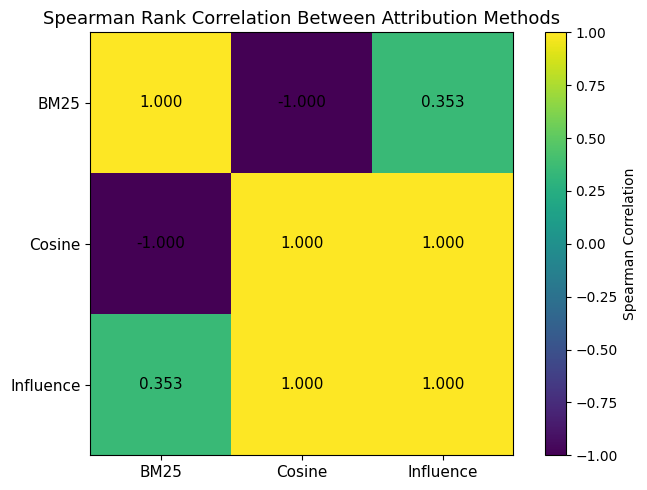

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "eval_df" not in globals():
    raise NameError("eval_df is not defined. Run the evaluation metrics cell first.")

PLOT_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
bm25_cosine_mean = float(np.nanmean(eval_df["bm25_vs_cosine_rank"]))
bm25_influence_mean = float(np.nanmean(eval_df["bm25_vs_influence_rank"]))
cosine_influence_mean = float(np.nanmean(eval_df["cosine_vs_influence_rank"]))

spearman_matrix = pd.DataFrame(
    [
        [1.0,                 bm25_cosine_mean,      bm25_influence_mean],
        [bm25_cosine_mean,    1.0,                   cosine_influence_mean],
        [bm25_influence_mean, cosine_influence_mean, 1.0]
    ],
    index=["BM25", "Cosine", "Influence"],
    columns=["BM25", "Cosine", "Influence"]
)

print("=" * 60)
print("Average Spearman Correlation Matrix")
print("=" * 60)
print(spearman_matrix.round(3))
print("=" * 60)

plt.figure(figsize=(7, 5))
im = plt.imshow(spearman_matrix, vmin=-1, vmax=1)

plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, fontsize=11)
plt.yticks(range(len(spearman_matrix.index)), spearman_matrix.index, fontsize=11)
plt.title("Spearman Rank Correlation Between Attribution Methods", fontsize=13)
for i in range(spearman_matrix.shape[0]):
    for j in range(spearman_matrix.shape[1]):
        plt.text(
            j, i,
            f"{spearman_matrix.iloc[i, j]:.3f}",
            ha="center", va="center", fontsize=11
        )

plt.colorbar(im, label="Spearman Correlation")
plt.tight_layout()

save_path = os.path.join(PLOT_DIR, "spearman_rank_correlation.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

# Plot 2: Top-K Overlap Plot

Average Top-K Overlap
BM25 vs Cosine            : 0.048
BM25 vs Influence         : 0.252
Cosine vs Influence       : 0.076
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/plots/top_k_overlap.png


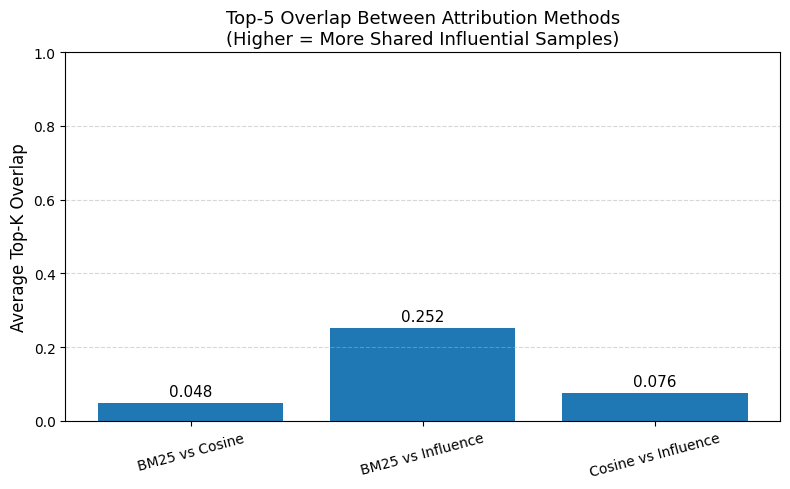

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

if "eval_df" not in globals():
    raise NameError("eval_df is not defined. Run evaluation metrics cell first.")

PLOT_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

overlap_labels = [
    "BM25 vs Cosine",
    "BM25 vs Influence",
    "Cosine vs Influence"
]

overlap_values = [
    float(np.nanmean(eval_df["bm25_vs_cosine_overlap"])),
    float(np.nanmean(eval_df["bm25_vs_influence_overlap"])),
    float(np.nanmean(eval_df["cosine_vs_influence_overlap"]))
]

print("=" * 60)
print("Average Top-K Overlap")
print("=" * 60)
for label, value in zip(overlap_labels, overlap_values):
    print(f"{label:<25} : {value:.3f}")
print("=" * 60)

plt.figure(figsize=(8, 5))
bars = plt.bar(overlap_labels, overlap_values)

# Add value labels
for bar, value in zip(bars, overlap_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 1)
plt.ylabel("Average Top-K Overlap", fontsize=12)
plt.title(
    f"Top-{CFG['top_k']} Overlap Between Attribution Methods\n(Higher = More Shared Influential Samples)",
    fontsize=13
)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

save_path = os.path.join(PLOT_DIR, "top_k_overlap.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

# Plot 3: Privacy Leakage Plot

Membership Inference ROC Results
Cosine Similarity  AUC : 0.443
Influence Score    AUC : 0.431
Interpretation: No strong privacy leakage is observed in the current setup.
Saved: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/plots/privacy_membership_inference_roc.png


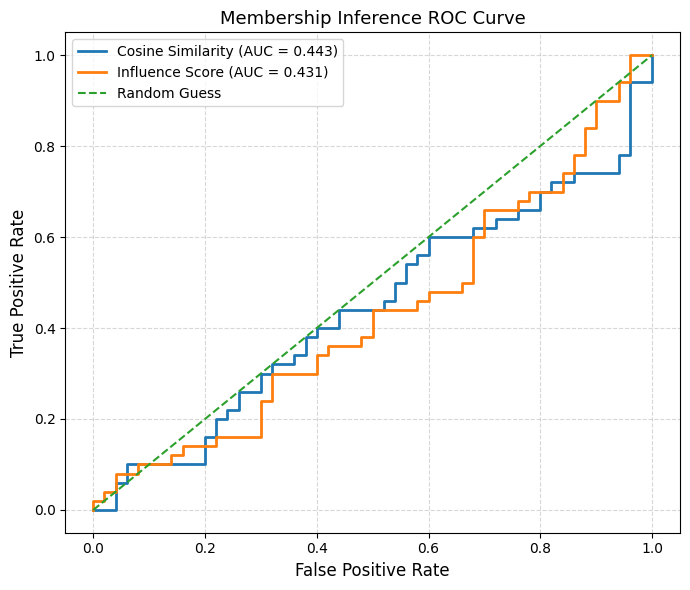

In [30]:
# ROC Curve for Membership Inference

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

if "privacy_df" not in globals():
    raise NameError("privacy_df is not defined. Run the privacy leakage metrics cell first.")

PLOT_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

y_true = privacy_df["label"].values
cos_scores = privacy_df["max_cosine"].values
inf_scores = privacy_df["max_influence"].values

fpr_cos, tpr_cos, _ = roc_curve(y_true, cos_scores)
fpr_inf, tpr_inf, _ = roc_curve(y_true, inf_scores)

auc_cos = roc_auc_score(y_true, cos_scores)
auc_inf = roc_auc_score(y_true, inf_scores)

print("=" * 70)
print("Membership Inference ROC Results")
print("=" * 70)
print(f"Cosine Similarity  AUC : {auc_cos:.3f}")
print(f"Influence Score    AUC : {auc_inf:.3f}")
print("=" * 70)

if auc_cos < 0.55 and auc_inf < 0.55:
    print("Interpretation: No strong privacy leakage is observed in the current setup.")
elif auc_cos > auc_inf:
    print("Interpretation: Cosine similarity shows stronger membership signal than influence score.")
else:
    print("Interpretation: Influence score shows stronger membership signal than cosine similarity.")

plt.figure(figsize=(7, 6))
plt.plot(fpr_cos, tpr_cos, linewidth=2, label=f"Cosine Similarity (AUC = {auc_cos:.3f})")
plt.plot(fpr_inf, tpr_inf, linewidth=2, label=f"Influence Score (AUC = {auc_inf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Membership Inference ROC Curve", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

save_path = os.path.join(PLOT_DIR, "privacy_membership_inference_roc.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

# Plot 4: First-Order Loss Impact Approximation

FIRST-ORDER LOSS IMPACT APPROXIMATION COMPLETED
loss_change_df shape: (500, 8)
Saved CSV: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/loss_change_approx.csv



,test_idx,test_alpaca_idx,method,rank,train_idx,train_alpaca_idx,score,approx_loss_change
0,0,21990,cosine,1,212,49588,0.461214,-0.461214
1,0,21990,cosine,2,311,34239,0.433529,-0.433529
2,0,21990,cosine,3,172,19548,0.423019,-0.423019
3,0,21990,cosine,4,184,3905,0.404701,-0.404701
4,0,21990,cosine,5,358,46250,0.395388,-0.395388


LOSS CHANGE SUMMARY
Cosine    count     : 250
Cosine    mean ΔL   : -0.609367
Cosine    std ΔL    : 0.091623
Influence count     : 250
Influence mean ΔL   : -0.012052
Influence std ΔL    : 0.012042
Saved plot: /content/drive/MyDrive/dataset-attribution-artifacts/outputs/runs/final_report_run/attribution_no_logix/plots/approximate_loss_change.png


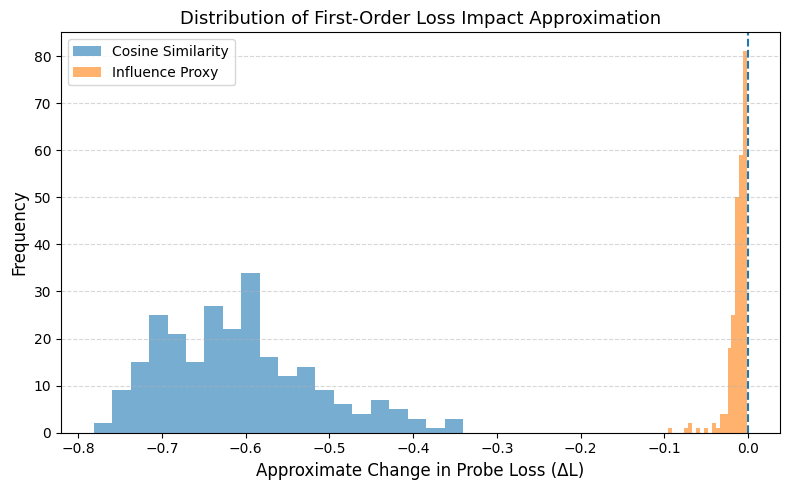

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_dfs = ["method2_results_df", "method3_results_df", "RESULTS_DIR"]
for name in required_dfs:
    if name not in globals():
        raise NameError(f"{name} is not defined. Run the attribution method cells first.")

PLOT_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

loss_change_rows = []

for method_name, df_method in [
    ("cosine", method2_results_df),
    ("influence", method3_results_df),
]:
    df_method = df_method.copy()

    for _, row in df_method.iterrows():
        score = float(row["score"])
        approx_delta_loss = -score

        loss_change_rows.append({
            "test_idx": int(row["test_idx"]),
            "test_alpaca_idx": int(row["test_alpaca_idx"]) if "test_alpaca_idx" in df_method.columns else int(row["test_idx"]),
            "method": method_name,
            "rank": int(row["rank"]),
            "train_idx": int(row["train_idx"]),
            "train_alpaca_idx": int(row["train_alpaca_idx"]) if "train_alpaca_idx" in df_method.columns else int(row["train_idx"]),
            "score": score,
            "approx_loss_change": float(approx_delta_loss),
        })

loss_change_df = pd.DataFrame(loss_change_rows)

csv_path = os.path.join(RESULTS_DIR, "loss_change_approx.csv")
loss_change_df.to_csv(csv_path, index=False)

print("=" * 80)
print("FIRST-ORDER LOSS IMPACT APPROXIMATION COMPLETED")
print("=" * 80)
print("loss_change_df shape:", loss_change_df.shape)
print("Saved CSV:", csv_path)
print()

display(loss_change_df.head())

cos_vals = loss_change_df.loc[
    loss_change_df["method"] == "cosine", "approx_loss_change"
].to_numpy(dtype=np.float32)

inf_vals = loss_change_df.loc[
    loss_change_df["method"] == "influence", "approx_loss_change"
].to_numpy(dtype=np.float32)

cos_vals = cos_vals[~np.isnan(cos_vals)]
inf_vals = inf_vals[~np.isnan(inf_vals)]

print("=" * 80)
print("LOSS CHANGE SUMMARY")
print("=" * 80)
print(f"Cosine    count     : {len(cos_vals)}")
print(f"Cosine    mean ΔL   : {np.mean(cos_vals):.6f}")
print(f"Cosine    std ΔL    : {np.std(cos_vals):.6f}")
print(f"Influence count     : {len(inf_vals)}")
print(f"Influence mean ΔL   : {np.mean(inf_vals):.6f}")
print(f"Influence std ΔL    : {np.std(inf_vals):.6f}")
print("=" * 80)

plt.figure(figsize=(8, 5))

plt.hist(cos_vals, bins=20, alpha=0.6, label="Cosine Similarity")
plt.hist(inf_vals, bins=20, alpha=0.6, label="Influence Proxy")

plt.axvline(0.0, linestyle="--", linewidth=1.5)

plt.title("Distribution of First-Order Loss Impact Approximation", fontsize=13)
plt.xlabel("Approximate Change in Probe Loss (ΔL)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plot_path = os.path.join(PLOT_DIR, "approximate_loss_change.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path)

plt.show()


# Case Study: Copyright Attribution & Privacy Leakage on Stanford Alpaca


In [ ]:
import numpy as np
import pandas as pd

probe_grads = []
probe_losses = []

def l2_normalize(x, eps=1e-12):
    denom = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / np.clip(denom, eps, None)

train_grads_f32 = train_grads.astype(np.float32)
train_grads_norm = l2_normalize(train_grads_f32)

def run_case_study_probe(probe, probe_grad):

    query_text = probe["full_text"]
    top_k = CFG["top_k"]

    bm25_topk, bm25_scores = retrieval_proxy_shortlist(
        query_text=query_text,
        top_n=top_k
    )

    qg_norm = probe_grad / (np.linalg.norm(probe_grad) + 1e-12)

    cos_scores_all = train_grads_norm @ qg_norm
    cos_rank = np.argsort(cos_scores_all)[::-1]

    cos_topk = cos_rank[:top_k]
    cos_scores = cos_scores_all[cos_rank][:top_k]

    shortlist_idx, _ = retrieval_proxy_shortlist(query_text, top_n=50)

    cand_grads = train_grads_f32[shortlist_idx]
    inf_scores_all = cand_grads @ probe_grad

    inf_rank = np.argsort(inf_scores_all)[::-1]

    inf_topk = shortlist_idx[inf_rank][:top_k]
    inf_scores = inf_scores_all[inf_rank][:top_k]

    def overlap(a, b):
        return len(set(a).intersection(set(b))) / float(top_k)

    return {
        "probe_id": probe["probe_id"],

        "bm25_topk": bm25_topk.tolist(),
        "cos_topk": cos_topk.tolist(),
        "inf_topk": inf_topk.tolist(),

        "bm25_scores": list(map(float, bm25_scores)),
        "cos_scores": list(map(float, cos_scores)),
        "inf_scores": list(map(float, inf_scores)),

        "bm25_vs_cos_overlap": overlap(bm25_topk, cos_topk),
        "bm25_vs_inf_overlap": overlap(bm25_topk, inf_topk),
        "cos_vs_inf_overlap": overlap(cos_topk, inf_topk),
    }

case_results = []

for probe, pg in zip(PROBE_QUERIES, probe_grads):
    result = run_case_study_probe(probe, pg)
    case_results.append(result)

    print("\n" + "=" * 80)
    print(f"Probe: {result['probe_id']}")
    print("=" * 80)

    print(f"BM25 vs Cosine overlap   : {result['bm25_vs_cos_overlap']:.2f}")
    print(f"BM25 vs Influence overlap: {result['bm25_vs_inf_overlap']:.2f}")
    print(f"Cosine vs Influence      : {result['cos_vs_inf_overlap']:.2f}")

case_df = pd.DataFrame(case_results)
display(case_df)

def show_samples(indices, title):
    print("\n" + "-" * 50)
    print(title)
    print("-" * 50)
    for i in indices:
        row = train_df.iloc[i]
        print(f"Index: {i}")
        print("Instruction:", row.get("instruction", ""))
        print()

for res in case_results:
    show_samples(res["bm25_topk"], "BM25 Top-K")
    show_samples(res["cos_topk"], "Cosine Top-K")
    show_samples(res["inf_topk"], "Influence Top-K")

In [42]:
PROBE_QUERIES = [
    {
        "probe_id": "PROBE-LEGAL-1",
        "category": "Regulatory Compliance / Legal Content",
        "copyright_risk": "Compliance — legal/regulatory knowledge related to labor laws and worker rights",
        "instruction": "Generate a headline for a newspaper article about a new law protecting worker rights.",
        "full_text": (
            "Instruction: Generate a headline for a newspaper article about a new law protecting worker rights.\n"
            "Response: New Legislation Protects Workers' Rights Nationwide"
        ),
    },
]

In [43]:
# Verify Retrieval Quality

from difflib import SequenceMatcher

def text_overlap_ratio(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

def audit_retrieved_samples(result, probe, train_df, method_key, score_key):
    rows = []
    for idx, score in zip(result[method_key], result[score_key]):
        row = train_df.iloc[idx]
        train_text = str(row.get("output", "")) + " " + str(row.get("instruction", ""))
        probe_response = probe["full_text"]

        overlap = text_overlap_ratio(probe_response, train_text)

        rows.append({
            "train_idx": idx,
            "method_score": score,
            "text_overlap_ratio": overlap,
            "instruction": row.get("instruction", ""),
            "output": str(row.get("output", ""))[:120],
        })
    return pd.DataFrame(rows)

# Run for each probe and method
for result, probe in zip(case_results, PROBE_QUERIES):
    print(f"\n=== {result['probe_id']} — BM25 Retrieval Audit ===")
    audit_df = audit_retrieved_samples(result, probe, train_df, "bm25_topk", "bm25_scores")
    display(audit_df)

    print(f"\n=== {result['probe_id']} — Cosine Retrieval Audit ===")
    audit_df = audit_retrieved_samples(result, probe, train_df, "cos_topk", "cos_scores")
    display(audit_df)


=== PROBE-LEGAL-1 — BM25 Retrieval Audit ===


,train_idx,method_score,text_overlap_ratio,instruction,output
0,45,0.841703,0.310680,Come up with a headline for a news article reg...,Boston Residents Face High Cost of Living Crisis
1,423,0.746394,0.361582,Generate a catchy headline for an article abou...,"""Surprising Benefits of Building with Bamboo: ..."
2,128,0.662652,0.054348,Generate a writing prompt about exploring a ne...,Write a story about a person who travels to a ...
3,597,0.611202,0.048913,Create a tweet to promote the importance of ma...,Wearing a mask isn't just about protecting you...
4,567,0.520944,0.342679,Generate a title for an article about artifici...,The Rise of the Smart Machines: The Potential ...



=== PROBE-LEGAL-1 — Cosine Retrieval Audit ===


,train_idx,method_score,text_overlap_ratio,instruction,output
0,264,0.774849,0.010499,Generate a hypothesis about the cause of clima...,The rise in global temperatures is likely caus...
1,477,0.745726,0.070093,Generate an activity that a family can do toge...,One activity that a family can do together on ...
2,567,0.744996,0.342679,Generate a title for an article about artifici...,The Rise of the Smart Machines: The Potential ...
3,319,0.724209,0.151515,Write an imperative sentence providing instruc...,Turn the doorknob to open the door.
4,98,0.717382,0.245283,Generate a numerical fact about the number 12.,"12 is the smallest abundant number, which mean..."


In [44]:
# Method Disagreement

def find_disagreements(result, train_df, top_k=5):
    bm25_set = set(result["bm25_topk"][:top_k])
    cos_set   = set(result["cos_topk"][:top_k])
    inf_set   = set(result["inf_topk"][:top_k])

    only_bm25   = bm25_set - cos_set - inf_set
    only_cos    = cos_set - bm25_set - inf_set
    only_inf    = inf_set - bm25_set - cos_set
    all_agree   = bm25_set & cos_set & inf_set

    print(f"\nProbe: {result['probe_id']}")
    print(f"All 3 methods agree on     : {sorted(all_agree)}")
    print(f"Only BM25 retrieved        : {sorted(only_bm25)}")
    print(f"Only Cosine retrieved      : {sorted(only_cos)}")
    print(f"Only Influence retrieved   : {sorted(only_inf)}")

    print("\nSamples ONLY BM25 found (lexically similar but not gradient-similar):")
    for idx in only_bm25:
        row = train_df.iloc[idx]
        print(f"  [{idx}] {row.get('instruction','')[:100]}")

    print("\nSamples ONLY Cosine found (gradient-similar but not lexically similar):")
    for idx in only_cos:
        row = train_df.iloc[idx]
        print(f"  [{idx}] {row.get('instruction','')[:100]}")

for result in case_results:
    find_disagreements(result, train_df)


Probe: PROBE-LEGAL-1
All 3 methods agree on     : [567]
Only BM25 retrieved        : [45, 128, 597]
Only Cosine retrieved      : [98, 264, 319, 477]
Only Influence retrieved   : [281, 313, 486]

Samples ONLY BM25 found (lexically similar but not gradient-similar):
  [128] Generate a writing prompt about exploring a new place.
  [45] Come up with a headline for a news article regarding the increased cost of living in a certain city.
  [597] Create a tweet to promote the importance of mask-wearing during the Covid-19 pandemic.

Samples ONLY Cosine found (gradient-similar but not lexically similar):
  [264] Generate a hypothesis about the cause of climate change
  [98] Generate a numerical fact about the number 12.
  [477] Generate an activity that a family can do together on a weekend.
  [319] Write an imperative sentence providing instruction on opening a door


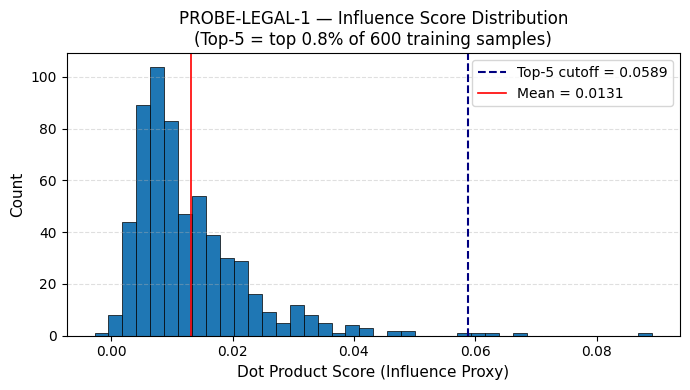

In [45]:
# Score Distribution Plot Per Probe

import matplotlib.pyplot as plt
import numpy as np

def plot_score_distribution(probe_grad, train_grads_f32, probe_id, plot_dir):
    inf_scores = train_grads_f32 @ probe_grad

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(inf_scores, bins=40, edgecolor="black", linewidth=0.5)

    top5_cutoff = np.sort(inf_scores)[-5]
    mean_score = inf_scores.mean()
    pct_above = (inf_scores >= top5_cutoff).mean() * 100

    ax.axvline(
        top5_cutoff,
        linestyle="--",
        color="navy",
        label=f"Top-5 cutoff = {top5_cutoff:.4f}"
    )
    ax.axvline(
        mean_score,
        linestyle="-",
        color="red",
        linewidth=1.2,
        label=f"Mean = {mean_score:.4f}"
    )

    ax.set_title(
        f"{probe_id} — Influence Score Distribution\n"
        f"(Top-5 = top {pct_above:.1f}% of {len(inf_scores)} training samples)",
        fontsize=12
    )
    ax.set_xlabel("Dot Product Score (Influence Proxy)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(
        os.path.join(plot_dir, f"{probe_id}_influence_score_distribution.png"),
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

for probe, pg in zip(PROBE_QUERIES, probe_grads):
    plot_score_distribution(
        probe_grad=pg,
        train_grads_f32=train_grads_f32,
        probe_id=probe["probe_id"],
        plot_dir=CASE_STUDY_DIR
    )